# Download data (skips if data is already there

In [1]:
%run scripts/download_data.py

Skipping part1.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part1.tar.gz
Skipping part2.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part2.tar.gz
Skipping part3.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part3.tar.gz
Done.


# Unzip files  - skip if raw data directories already exist

In [4]:
import os

# Check if the folder is empty; if so, extract the files
if os.path.isdir("data/raw/utkface/part1"):
    print("Already extracted part1, skipping.")
else:
    !tar -xzf data/raw/utkface/part1.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part2"):
    print("Already extracted part2, skipping.")
else:
    !tar -xzf data/raw/utkface/part2.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part3"):
    print("Already extracted part3, skipping.")
else:
    !tar -xzf data/raw/utkface/part3.tar.gz -C data/raw/utkface


Already extracted part1, skipping.
Already extracted part2, skipping.
Already extracted part3, skipping.


# Preprocess data

In [1]:
%run scripts/preprocess_data.py

Reproducibility: Random seed set to 42
Called from /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/scripts/preprocess_data.py:42 in function main
RAW_DATA_DIR exists: True
RAW_DATA_DIR path: data/raw/utkface
data/raw/utkface -> 3 files
data/raw/utkface/part1 -> 10137 files
data/raw/utkface/part2 -> 10719 files
data/raw/utkface/part3 -> 3253 files
Skipped samples: 5
Train: 19283 | Valid: 2410 | Test: 2411
Sample skipped: [('61_1_20170109142408075.jpg', 'invalid_filename'), ('61_3_20170109150557335.jpg', 'invalid_filename'), ('39_1_20170116174525125.jpg', 'invalid_filename'), ('53__0_20170116184028385.jpg', 'invalid_filename'), ('.DS_Store', 'invalid_filename')]

[train] age statistics (n=19283)
  min=1  max=116  mean=33.05  median=29.0  std=20.11

[val] age statistics (n=2410)
  min=1  max=116  mean=33.11  median=29.0  std=20.22

[test] age statistics (n=2411)
  min=1  max=116  mean=32.96  median=29.0  std=20.31


# Print selected config file

In [2]:
!cat configs/linear_regression_untrained.yaml

# Config file for ResNet18 untrained, to be used as backbone for linear regression.

experiment_name: "linear_regression_untrained"
model_name: "linear"  # linear, mlp, or mlp_dropout
seed: 42
pretrained: False
freeze_backbone: False    # Whether to fine-tune the pretrained model or just use it as a feature extractor
task: "regression"  # regression or classification
metric: "mae"       # mse for regression, accuracy for classification

# Data parameters
batch_size: 32
num_workers: 4
image_size: 224

# Training parameters
epochs: 20
learning_rate: 0.001
optimizer: "Adam"
#loss_function: "MSELoss" unused since we set it in train.py based on task
save_best: True
weight_decay: 0.001

# MLP + Dropout
dropout: 0.2


# Train randomly initialized ResNet18

Reproducibility: Random seed set to 42
Pipeline Initialized. Loading data and model...
Using AdamW optimizer with weight decay: 0.001
Setup complete! Ready to begin training epochs.


100%|###########################################################################################################################################| 76/76 [00:32<00:00,  2.37it/s, loss=353]


Epoch [1/20] Train Loss: 409.7445, Train MAE: 15.4898, Train MSE: 409.7445, Train Acc@3: 0.1429, Train Acc@5: 0.2325 | Val Loss: 353.0362, Val MAE: 14.2950, Val MSE: 353.0362, Val Acc@3: 0.1685, Val Acc@5: 0.2585, Val MAE: 14.2950


100%|###########################################################################################################################################| 76/76 [00:31<00:00,  2.40it/s, loss=344]


Epoch [2/20] Train Loss: 356.1606, Train MAE: 14.5005, Train MSE: 356.1606, Train Acc@3: 0.1507, Train Acc@5: 0.2504 | Val Loss: 343.6752, Val MAE: 14.0509, Val MSE: 343.6752, Val Acc@3: 0.1407, Val Acc@5: 0.2344, Val MAE: 14.0509


...

Epoch [18/20] Train Loss: 98.4586, Train MAE: 7.3326, Train MSE: 98.4586, Train Acc@3: 0.3037, Train Acc@5: 0.4664 | Val Loss: 143.0122, Val MAE: 8.6822, Val MSE: 143.0122, Val Acc@3: 0.2635, Val Acc@5: 0.4166, Val MAE: 8.6822


100%|###########################################################################################################################################| 76/76 [00:45<00:00,  1.66it/s, loss=132]


Epoch [19/20] Train Loss: 91.4526, Train MAE: 7.1044, Train MSE: 91.4526, Train Acc@3: 0.3095, Train Acc@5: 0.4747 | Val Loss: 132.3650, Val MAE: 8.3681, Val MSE: 132.3650, Val Acc@3: 0.2602, Val Acc@5: 0.4220, Val MAE: 8.3681


100%|###########################################################################################################################################| 76/76 [00:32<00:00,  2.32it/s, loss=127]


Epoch [20/20] Train Loss: 80.4214, Train MAE: 6.7263, Train MSE: 80.4214, Train Acc@3: 0.3164, Train Acc@5: 0.4933 | Val Loss: 126.5198, Val MAE: 8.2491, Val MSE: 126.5198, Val Acc@3: 0.2697, Val Acc@5: 0.4278, Val MAE: 8.2491
Saving Best Val MAE: 8.2491 at Epoch 20
Saved model with MAE = 8.2491
Saved training stats history to /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/stats_history_linear_regression_untrained.npy
Training completely finished! Best Val Loss: 126.5198, Best Val MAE: 8.2491


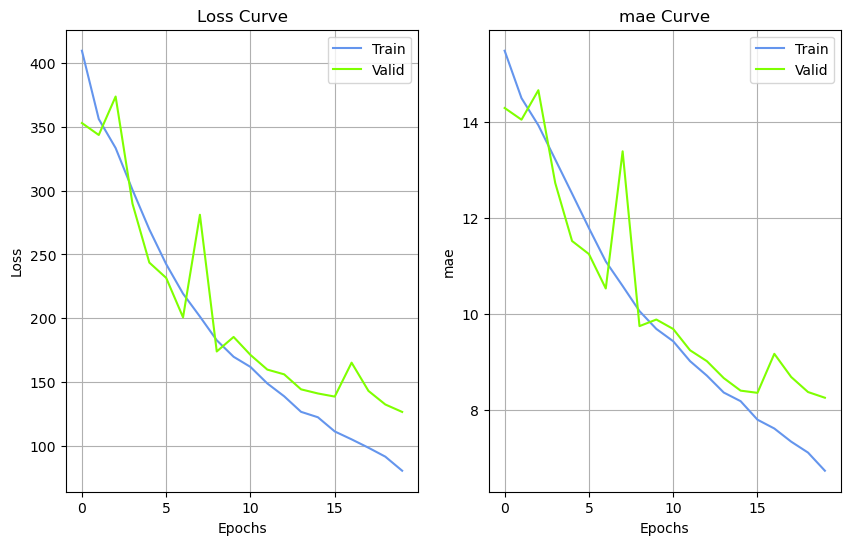

In [1]:
%run scripts/train.py --config configs/linear_regression_untrained.yaml

# Evaluate randomly initialized ResNet18

In [2]:
%run scripts/evaluate.py --config configs/linear_regression_untrained.yaml

Reproducibility: Random seed set to 42
Configuration loaded. Loading data and model...
Loading model from checkpoint: /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/checkpoint_linear_regression_untrained.pth


100%|###########################################################################################################################################| 76/76 [00:31<00:00,  2.42it/s, loss=128]


Evaluation Metrics — linear_regression_untrained
+--------+----------+
| Metric |    Value |
+--------+----------+
| MAE    |   8.2012 |
| MSE    | 127.8722 |
| Acc@3  |   0.2791 |
| Acc@5  |   0.4301 |
+--------+----------+


# Plot Validation Curve by Epoch

Epochs 0-10: Best Val MAE = 9.7435
Epochs 0-20: Best Val MAE = 8.2491


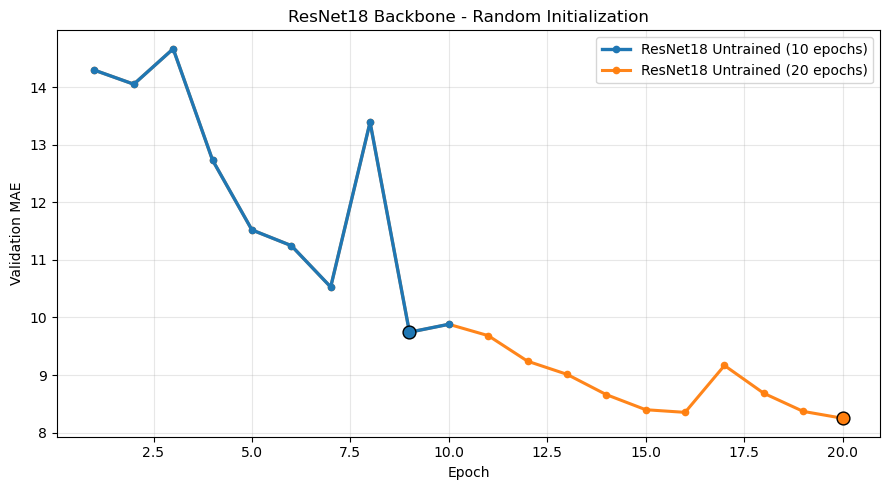

In [4]:
import numpy
from src.utils.plots import plot_validation_curves
# Load the file into a variable
data = numpy.load('outputs/stats_history_linear_regression_untrained.npy', allow_pickle=True).item()

plot_validation_curves(data['eval'], title='ResNet18 Backbone - Random Initialization', label='ResNet18 Untrained')